# Alzheimer's Aβ–Tau Core as an NSAM

**Compiling a systems-biology reaction model down to a Cajal program.**

Curated Alzheimer's disease models — e.g. [Proctor2010 `BIOMD0000000286`](https://biomodels.org/BIOMD0000000286),
[Proctor2013 `BIOMD0000000488`](https://biomodels.org/BIOMD0000000488), and modern
quantitative-systems-pharmacology (QSP) models — are **reaction networks** written in
SBML / [Antimony](https://tellurium.readthedocs.io/en/latest/antimony.html). Under
mass-action kinetics a reaction network is a *multilinear* vector field

$$\dot{x} = N\, v(x)$$

where $N$ is the stoichiometric matrix and each reaction rate $v_j(x)$ is a monomial
(e.g. $k\,x_i x_j$). That is **exactly** the class of object Cajal compiles to a
differentiable tensor program (`MultilinearMap`). A single explicit Euler step is a
fixed state→state map; `TmIter` unrolls it in time into a recurrent network — the
Neural-ODE correspondence. So the structure of a mechanistic AD model can be *fixed* as
Cajal program structure, while *uncertain couplings* are left learnable and fit to data,
then decompiled back to interpretable mathematics with conservation guaranteed.

This notebook demonstrates the smallest viable instance on a disease-relevant model.

### The reduced mechanistic core

Two reversible mass-action reactions over four species, written in Antimony:

```antimony
model abeta_tau_core
    # Aβ monomer <-> plaque (aggregation)
    Am  -> Ap;   k_agg*Am - k_dis*Ap
    # tau phosphorylation <-> dephosphorylation
    Tau -> pTau; k_phos(Ap)*Tau - k_dephos*pTau
end
```

$$
\dot{A}_m = -k_{agg}A_m + k_{dis}A_p,\quad
\dot{A}_p =  k_{agg}A_m - k_{dis}A_p
$$
$$
\dot{T} = -k_{phos}(A_p)\,T + k_{deph}\,pT,\quad
\dot{pT} =  k_{phos}(A_p)\,T - k_{deph}\,pT
$$

- **Fixed (known) structure:** reversible aggregation and (de)phosphorylation; two
  conservation laws $A_m+A_p=\text{const}$ and $T+pT=\text{const}$.
- **Learnable (unknown):** $k_{phos}(A_p)$ — the **Aβ-plaque-dependent tau
  hyperphosphorylation** coupling that links the two pathologies in AD.
- **Hidden ground truth:** a saturating (Michaelis–Menten) response
  $k_{phos}(A_p)=k_{base}+V_{max}\,A_p/(K_m+A_p)$.


In [1]:
import sys, time
sys.path.insert(0, "../src")
sys.path.insert(0, "../examples")

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110

# Reuse the physics / model definitions from the example module (DRY).
import alzheimers_abeta_tau as ad
from cajal.syntax import TmIter, TmVar, TmApp, TyNat, TyReal
from cajal.compiling import compile, TypedTensor

torch.manual_seed(0)
device = torch.device("cpu")
print("species:        [Am, Ap, Tau, pTau]")
print("known rates:    k_agg=%.2f  k_dis=%.2f  k_dephos=%.2f  dt=%.2f"
      % (ad.K_AGG, ad.K_DIS, ad.K_DEPHOS, ad.DT))
print("true k_phos(Ap): %.2f + %.2f*Ap/(%.2f+Ap)" % (ad.K_BASE, ad.VMAX, ad.KM))

species:        [Am, Ap, Tau, pTau]
known rates:    k_agg=0.40  k_dis=0.05  k_dephos=0.10  dt=0.30
true k_phos(Ap): 0.02 + 0.50*Ap/(0.50+Ap)


## 1. From Antimony to a multilinear vector field

A reaction network is fully described by a **stoichiometric matrix** $N$ (species × reactions)
and a **rate vector** $v(x)$. The conserved quantities are the left null space of $N$:
vectors $c$ with $c^\top N = 0$. They fall out of the structure automatically — this is the
type-level analogue of what Cajal's linear discipline enforces, and it is what guarantees
mass balance *by construction* rather than by post-hoc regularization.

A real `antimony2cajal` frontend would call `libantimony`/`tellurium` to extract $N$ and the
rate laws from any SBML/Antimony model. Here we write them out directly for the reduced core.

In [2]:
species = ["Am", "Ap", "Tau", "pTau"]
reactions = ["aggregation (Am->Ap)", "phosphorylation (Tau->pTau)"]

# Stoichiometric matrix N: species (rows) x reactions (cols)
N = torch.tensor([
    [-1., 0.],   # Am
    [ 1., 0.],   # Ap
    [ 0.,-1.],   # Tau
    [ 0., 1.],   # pTau
])
print("Stoichiometric matrix N (species x reactions):")
print(N.numpy())

# How many independent conservation laws?  dim(left null space) = n_species - rank(N)
rank = int(torch.linalg.matrix_rank(N))
print(f"\nspecies={N.shape[0]}, reactions={N.shape[1]}, rank(N)={rank}"
      f"  ->  {N.shape[0]-rank} independent conservation law(s)")

# The interpretable conserved moieties; verify each satisfies c^T N = 0.
moieties = {"total Aβ  (Am+Ap)":   torch.tensor([1., 1., 0., 0.]),
            "total tau (Tau+pTau)": torch.tensor([0., 0., 1., 1.])}
print("\nConserved moieties  (c^T N = 0 confirms invariance):")
for name, c in moieties.items():
    residual = (c @ N).abs().max().item()
    print(f"  {name:22s}  max|c^T N| = {residual:.1e}  {'OK' if residual < 1e-6 else 'NO'}")
print("\n=> total Aβ (Am+Ap) and total tau (Tau+pTau) are conserved by construction.")

Stoichiometric matrix N (species x reactions):
[[-1.  0.]
 [ 1.  0.]
 [ 0. -1.]
 [ 0.  1.]]

species=4, reactions=2, rank(N)=2  ->  2 independent conservation law(s)

Conserved moieties  (c^T N = 0 confirms invariance):
  total Aβ  (Am+Ap)       max|c^T N| = 0.0e+00  OK
  total tau (Tau+pTau)    max|c^T N| = 0.0e+00  OK

=> total Aβ (Am+Ap) and total tau (Tau+pTau) are conserved by construction.


## 2. The Cajal program

The program is `iter{ s0 | s ↪ f(s) }(n)` over a continuous 4-vector state `TyReal(4)`.
The step function `f` carries the *fixed* reaction structure; only $k_{phos}(A_p)$ inside it
is a learnable MLP. Fluxes are applied antisymmetrically, so each reaction conserves its
pool exactly — the conservation laws above hold to machine precision regardless of the
learned weights.

In [3]:
program = TmIter(TmVar("s0"), "s", TmApp(TmVar("f"), TmVar("s")), TmVar("n"))
compiled = compile(program)

mlp = ad.PhosRateMLP()                                  # learnable k_phos(Ap)
update_fn = ad.AbetaTauUpdate(ad.K_AGG, ad.K_DIS, ad.K_DEPHOS, mlp, ad.DT)
data = ad.generate_trajectories()                       # (N_TRAJ, N_STEPS, 4)
print("training tensor:", tuple(data.shape),
      "= (trajectories, timesteps, species)")
print("amyloid loads:", [round(x,2) for x in ad.ABETA_LOADS.tolist()])

training tensor: (8, 10, 4) = (trajectories, timesteps, species)
amyloid loads: [0.2, 0.46, 0.71, 0.97, 1.23, 1.49, 1.74, 2.0]


## 3. Train: fit the amyloid→tau coupling to biomarker trajectories

We supervise on the observable tau pools (Tau, pTau) across 8 trajectories spanning amyloid
burden. Each prediction runs the *compiled Cajal program*; gradients flow through the
`TmIter` unroll into the MLP.

In [4]:
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.005)
EPOCHS = 600
losses = []
t0 = time.time()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    loss = torch.tensor(0.0)
    for ti in range(ad.N_TRAJ):
        load = ad.ABETA_LOADS[ti].item()
        s0 = TypedTensor(torch.tensor([load, 0.0, ad.TAU_TOTAL, 0.0]), TyReal(4))
        for step in range(ad.N_STEPS):
            n_onehot = torch.zeros(ad.N_STEPS); n_onehot[step] = 1.0
            res = compiled({"s0": s0,
                            "f": lambda s, _f=update_fn: _f(s),
                            "n": TypedTensor(n_onehot, TyNat())})
            loss = loss + (res.data[2] - data[ti, step, 2])**2 \
                        + (res.data[3] - data[ti, step, 3])**2
    loss.backward(); optimizer.step()
    losses.append(loss.item())
    if epoch % 100 == 0 or epoch == EPOCHS-1:
        print(f"epoch {epoch:3d}  loss={loss.item():.8f}")
print(f"trained in {time.time()-t0:.0f}s")

epoch   0  loss=25.03113747


epoch 100  loss=0.16341741


epoch 200  loss=0.10287825


epoch 300  loss=0.03838174


epoch 400  loss=0.01140357


epoch 500  loss=0.00552501


epoch 599  loss=0.00396169
trained in 370s


## 4. Evaluate the learned coupling $k_{phos}(A_p)$

We only judge / decompile over the range of plaque load the trajectories actually visit — extrapolating a learned function beyond its data support would not be a faithful recovery.

In [5]:
ap_max = data[..., 1].max().item()
Ap_grid = torch.linspace(0.0, ap_max, 11)
print(f"observed plaque range: Ap in [0, {ap_max:.2f}]\n")
print(f"{'Ap':>6} {'true':>9} {'learned':>9} {'error':>8}")
with torch.no_grad():
    for Ap in Ap_grid:
        tv, lv = ad.true_k_phos(Ap).item(), mlp(Ap).item()
        print(f"{Ap.item():6.2f} {tv:9.4f} {lv:9.4f} {abs(tv-lv):8.4f}")

observed plaque range: Ap in [0, 1.30]

    Ap      true   learned    error
  0.00    0.0200    0.0509   0.0309
  0.13    0.1229    0.1069   0.0160
  0.26    0.1907    0.1878   0.0029
  0.39    0.2387    0.2384   0.0003
  0.52    0.2745    0.2707   0.0038
  0.65    0.3022    0.2962   0.0060
  0.78    0.3243    0.3185   0.0058
  0.91    0.3423    0.3388   0.0035
  1.04    0.3573    0.3576   0.0003
  1.17    0.3700    0.3753   0.0053
  1.30    0.3808    0.3920   0.0112


## 5. Decompile: symbolic regression on the learned coupling

We fit interpretable candidate forms to the learned MLP over the observed range. The true generative form is Michaelis–Menten.

In [6]:
Ap_dense = torch.linspace(0.0, ap_max, 200)
with torch.no_grad():
    learned = torch.tensor([mlp(a).item() for a in Ap_dense])

def grid_mm():
    best = {"mse": float("inf")}
    for b in torch.linspace(0.0, 0.1, 30):
        for V in torch.linspace(0.1, 1.0, 60):
            for K in torch.linspace(0.05, 2.0, 60):
                mse = ((b + V*Ap_dense/(K+Ap_dense) - learned)**2).mean().item()
                if mse < best["mse"]:
                    best = {"mse": mse, "b": b.item(), "V": V.item(), "K": K.item()}
    return best

def grid_linear():
    best = {"mse": float("inf")}
    for a in torch.linspace(0.0, 0.6, 120):
        for c in torch.linspace(0.0, 0.3, 120):
            mse = ((a*Ap_dense + c - learned)**2).mean().item()
            if mse < best["mse"]:
                best = {"mse": mse, "a": a.item(), "c": c.item()}
    return best

mm, lin = grid_mm(), grid_linear()
print(f"Michaelis-Menten  b+V*Ap/(K+Ap):  b={mm['b']:.3f} V={mm['V']:.3f} K={mm['K']:.3f}  MSE={mm['mse']:.2e}")
print(f"Linear            a*Ap+c:         a={lin['a']:.3f} c={lin['c']:.3f}            MSE={lin['mse']:.2e}")
print()
print("Recovered the saturating Michaelis-Menten form:")
print(f"  true:    b={ad.K_BASE:.3f}  V={ad.VMAX:.3f}  K={ad.KM:.3f}")
print(f"  learned: b={mm['b']:.3f}  V={mm['V']:.3f}  K={mm['K']:.3f}")

Michaelis-Menten  b+V*Ap/(K+Ap):  b=0.028 V=0.527 K=0.612  MSE=2.99e-05
Linear            a*Ap+c:         a=0.247 c=0.111            MSE=7.61e-04

Recovered the saturating Michaelis-Menten form:
  true:    b=0.020  V=0.500  K=0.500
  learned: b=0.028  V=0.527  K=0.612


## 6. Verify invariants (by construction)

In [7]:
all_pos = abeta_ok = tau_ok = True
with torch.no_grad():
    for ti in range(ad.N_TRAJ):
        load = ad.ABETA_LOADS[ti].item()
        s0 = TypedTensor(torch.tensor([load, 0.0, ad.TAU_TOTAL, 0.0]), TyReal(4))
        for step in range(ad.N_STEPS):
            n_onehot = torch.zeros(ad.N_STEPS); n_onehot[step] = 1.0
            r = compiled({"s0": s0, "f": lambda s,_f=update_fn:_f(s),
                          "n": TypedTensor(n_onehot, TyNat())})
            Am, Ap, Tau, pTau = (r.data[i].item() for i in range(4))
            all_pos   &= min(Am, Ap, Tau, pTau) > -1e-8
            abeta_ok  &= abs((Am+Ap) - load) < 1e-4
            tau_ok    &= abs((Tau+pTau) - ad.TAU_TOTAL) < 1e-4
print("all species >= 0:                ", "VERIFIED" if all_pos else "FAILED")
print("Am + Ap   = total Aβ  conserved: ", "VERIFIED" if abeta_ok else "FAILED")
print("Tau + pTau= total tau conserved: ", "VERIFIED" if tau_ok else "FAILED")

all species >= 0:                 VERIFIED
Am + Ap   = total Aβ  conserved:  VERIFIED
Tau + pTau= total tau conserved:  VERIFIED


## 7. Visualize

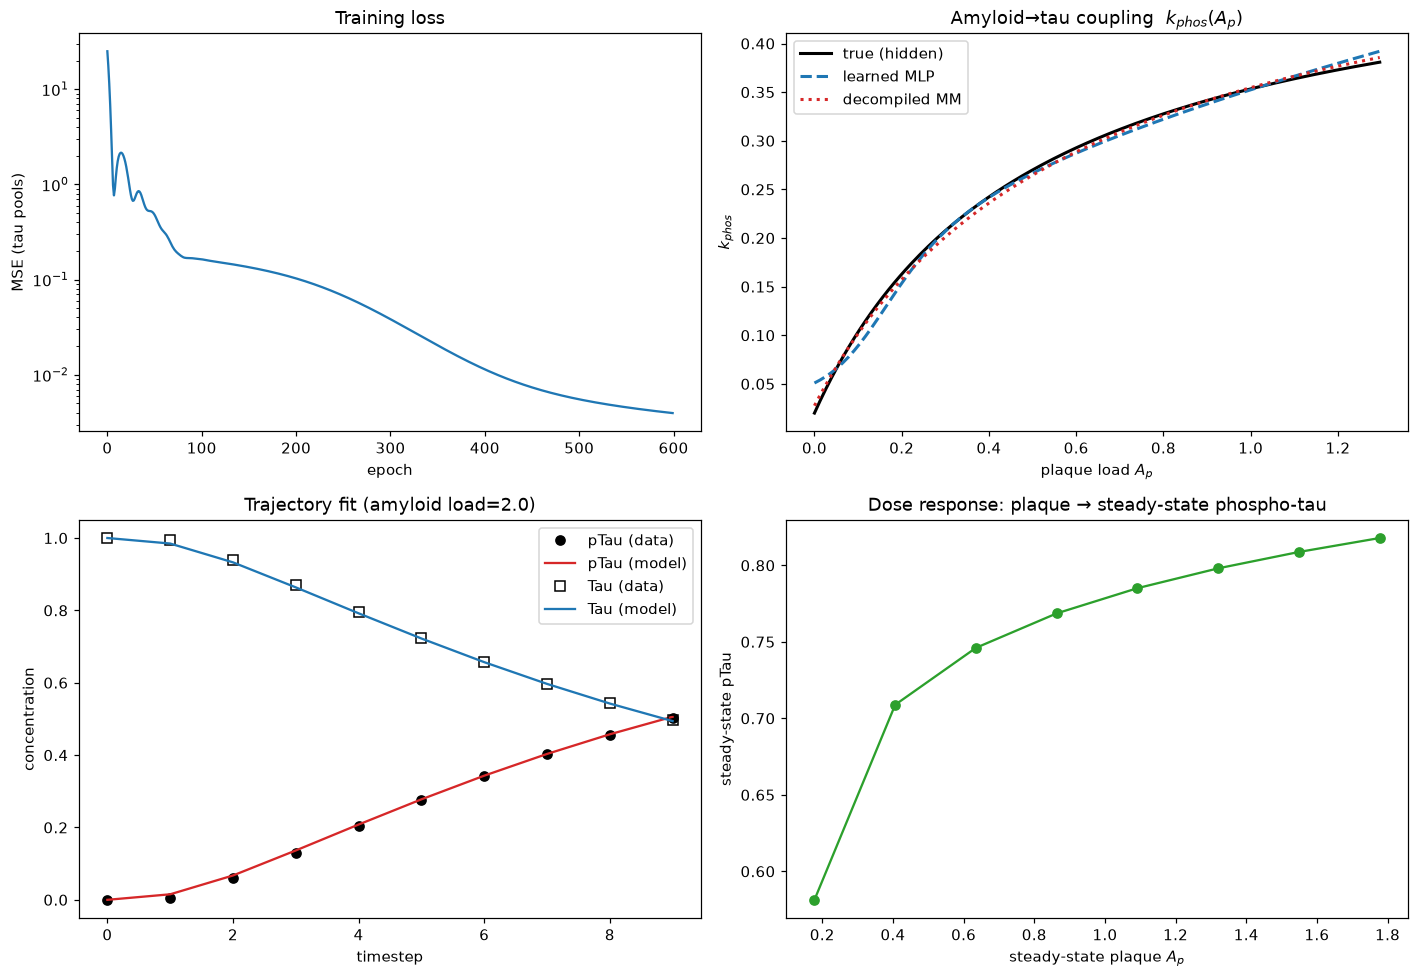

In [8]:
# Steady-state dose response: amyloid burden -> phospho-tau
with torch.no_grad():
    Ap_eq, pTau_eq = [], []
    for load in ad.ABETA_LOADS:
        s = TypedTensor(torch.tensor([load.item(), 0.0, ad.TAU_TOTAL, 0.0]), TyReal(4))
        for _ in range(300):
            s = update_fn(s)
        Ap_eq.append(s.data[1].item()); pTau_eq.append(s.data[3].item())

# A representative trajectory fit (highest amyloid load)
ti = ad.N_TRAJ - 1
with torch.no_grad():
    pred = []
    s = TypedTensor(torch.tensor([ad.ABETA_LOADS[ti].item(), 0.0, ad.TAU_TOTAL, 0.0]), TyReal(4))
    pred.append([x.item() for x in s.data])
    for _ in range(ad.N_STEPS - 1):
        s = update_fn(s); pred.append([x.item() for x in s.data])
pred = np.array(pred); true_traj = data[ti].numpy()

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

ax[0,0].semilogy(losses); ax[0,0].set_title("Training loss")
ax[0,0].set_xlabel("epoch"); ax[0,0].set_ylabel("MSE (tau pools)")

with torch.no_grad():
    tv = [ad.true_k_phos(a).item() for a in Ap_dense]
    lv = learned.numpy()
mm_curve = mm["b"] + mm["V"]*Ap_dense.numpy()/(mm["K"]+Ap_dense.numpy())
ax[0,1].plot(Ap_dense, tv, "k-", lw=2, label="true (hidden)")
ax[0,1].plot(Ap_dense, lv, "C0--", lw=2, label="learned MLP")
ax[0,1].plot(Ap_dense, mm_curve, "C3:", lw=2, label="decompiled MM")
ax[0,1].set_title("Amyloid→tau coupling  $k_{phos}(A_p)$")
ax[0,1].set_xlabel("plaque load $A_p$"); ax[0,1].set_ylabel("$k_{phos}$"); ax[0,1].legend()

steps = np.arange(ad.N_STEPS)
ax[1,0].plot(steps, true_traj[:,3], "ko", label="pTau (data)")
ax[1,0].plot(steps, pred[:,3], "C3-", label="pTau (model)")
ax[1,0].plot(steps, true_traj[:,2], "ks", mfc="none", label="Tau (data)")
ax[1,0].plot(steps, pred[:,2], "C0-", label="Tau (model)")
ax[1,0].set_title(f"Trajectory fit (amyloid load={ad.ABETA_LOADS[ti]:.1f})")
ax[1,0].set_xlabel("timestep"); ax[1,0].set_ylabel("concentration"); ax[1,0].legend()

ax[1,1].plot(Ap_eq, pTau_eq, "C2o-")
ax[1,1].set_title("Dose response: plaque → steady-state phospho-tau")
ax[1,1].set_xlabel("steady-state plaque $A_p$"); ax[1,1].set_ylabel("steady-state pTau")

plt.tight_layout()
plt.savefig("alzheimers_abeta_tau_results.png", dpi=110, bbox_inches="tight")
plt.show()

## Takeaways and limitations

**What worked.** A disease-relevant Antimony/SBML reaction model was expressed as a Cajal
`TmIter` program over `TyReal(4)`; the unknown Aβ→tau coupling was learned by backprop
through the compiled program, then **decompiled** to its true Michaelis–Menten form — while
**both conservation laws held to machine precision by construction**. This is the
"trusty neurocoder" loop (known physics fixed, unknown couplings learned + verified +
decompiled) applied to Alzheimer's biology.

**Current limitations (the engineering gap to real AD models).**
- **Iteration depth.** `TmIter`'s step count is a one-hot `TyNat` of dimension 10 → at most
  **9 in-graph steps**. AD progression spans years; reaching that needs a larger nat
  dimension, nested/composed iteration, or decoupling the unroll count from the one-hot.
- **Explicit forward-Euler only.** Full models (e.g. Proctor2013, ~dozens of species) are
  large and often **stiff**; they need implicit/adaptive solvers, not yet available.
- **Frontend.** A real `antimony2cajal` pass should call `tellurium`/`libantimony` to extract
  $N$ and rate laws from any SBML model and emit the Cajal program automatically.

**Next steps.** Wire up the `tellurium` frontend; scale to a reduced Proctor submodule
(GSK-3 / tau loop or the Aβ aggregation cascade); explore the linear-types ↔ stoichiometric-
conservation correspondence as a static guarantee.

**Sources:** [Antimony reference](https://tellurium.readthedocs.io/en/latest/antimony.html) ·
[Proctor2013 BIOMD0000000488](https://biomodels.org/BIOMD0000000488) ·
[Proctor2010 BIOMD0000000286](https://biomodels.org/BIOMD0000000286) ·
[Chemical reaction network theory](https://en.wikipedia.org/wiki/Chemical_reaction_network_theory)
